# OMPython Example
## Low Pass Filter from previous System

In [27]:
from OMPython import ModelicaSystem
from pathlib import Path
import matplotlib.pyplot as plt

### Signal Source

In [ ]:
dic_path = Path("/home/flo/repos/SystemSimulation/examples/Modelica/LowPassFilter/")
signal_source_path = dic_path / "SignalSource.mo"
print("Loading Modelica System from:", signal_source_path)

Loading Modelica System from: /home/flo/repos/SystemSimulation/examples/Modelica/LowPassFilter/SignalSource.mo


In [8]:
signal_source = ModelicaSystem(str(signal_source_path), "SignalSource")
signal_source.buildModel()


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




In [17]:
print("Outputs:    ", signal_source.getOutputs())
print("Inputs:     ", signal_source.getInputs())
print("Parameters: ", signal_source.getParameters())
print("Continuous: ", signal_source.getContinuous())

Outputs:     {'U_in': None}
Inputs:      {}
Parameters:  {'A1': '60.0', 'A2': '5.0', 'f1': '0.159', 'f2': '7.96'}
Continuous:  {'$cse1': None, '$cse2': None, 'U_in': None, 's1': None, 's2': None}


In [33]:
signal_source.setSimulationOptions(["startTime=0.0", "stopTime=10.0"])
signal_source.getSimulationOptions()

{'startTime': '0.0',
 'stopTime': '10.0',
 'stepSize': '0.002',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

In [34]:
signal_source.simulate()
time_vals, u_in_vals = signal_source.getSolutions(["time" ,"U_in"])

LOG_STDOUT        | warning | Start or stop time was overwritten, but no new integrator step size was provided.
|                 | info    | | Re-calculating step size for 500 intervals.
|                 | |       | | Add `stepSize=<value>` to `-override=` or override file to silence this warning.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


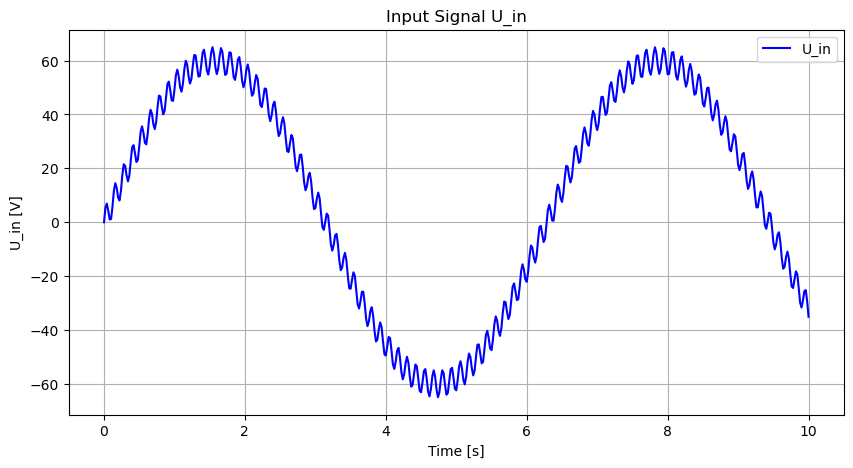

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(time_vals, u_in_vals, label="U_in", color='blue')
plt.title("Input Signal U_in")
plt.xlabel("Time [s]")
plt.ylabel("U_in [V]")
plt.grid()
plt.legend()
plt.show()


### Complete Filter System